In [1]:
# Importing libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
from collections import defaultdict
from scipy import stats
# from transformers import AutoTokenizer
# import re

In [ ]:
# Loading merged dataset

df_m = pd.read_csv("data/byproduct_data/merged.csv")

# Ensure structural columns are clean strings
df_m["info_order"] = df_m["info_order"].astype(str).str.strip()
df_m["info_thread.id"] = df_m["info_thread.id"].astype(str).str.strip()

# Keep a full backup copy of the original dataframe for splitting later
original_df_m = df_m.copy()

# A master dictionary to keep track of how many structural issues are in each thread
# Thread ID -> Count of errors
thread_error_counts = {}
sub_reply_orphan_counts = {}

broken_thread_ids = set()
orphan_rows = pd.DataFrame()
non_orphan_rows = pd.DataFrame()
replies_df_m = pd.DataFrame()
complete_pairs = 0
incomplete_pairs = 0
missing_title = 0
missing_post = 0
orphan_threads = 0
complete_threads = 0

print(f"Total Rows: {len(df_m)}")

Total Rows: 26550


In [ ]:
def orphan_and_title_post_pair_stats(df, complete_threads, orphan_threads):
    def get_parent_path_id(row):
        path = row["info_order"]
        thread = row["info_thread.id"]

        if "-" in path and "," not in path:
            if path.endswith("-post"):
                return None  # This guarantees a -post will never be flagged as a sub-reply orphan
            return None

        parts = [p.strip() for p in path.split(",")]
        if "-" in parts[0]:
            base_root = parts[0].split("-")[0]
        else:
            base_root = parts[0]

        if len(parts) == 2:
            expected_post_path = f"{thread} -> {base_root}-post"
            expected_title_path = f"{thread} -> {base_root}-title"
            
            # If the post exists, that's its normal parent
            if expected_post_path in existing_paths:
                return expected_post_path
            
            # NEW EXCEPTION: If post is missing but title exists, give it a pass (return None)
            elif expected_title_path in existing_paths:
                return None
                
            # If both post and title are totally missing, it's a true orphan
            return expected_post_path
        
        parent_path = ", ".join(parts[:-1])
        return f"{thread} -> {parent_path}"
    
    complete_pairs = 0
    incomplete_pairs = 0
    missing_post = 0
    missing_title = 0

    # Construct current path realities
    df["thread_path_id"] = df["info_thread.id"] + " -> " + df["info_order"]
    existing_paths = set(df["thread_path_id"].unique())

    # Calculate expected parent IDs
    df["expected_parent_path_id"] = df.apply(get_parent_path_id, axis=1)

    # Isolate replies that structurally demand a parent
    replies_df = df[df["expected_parent_path_id"].notna()]

    # Catch sub-replies missing their expected parent path
    is_orphan_mask = ~replies_df["expected_parent_path_id"].isin(existing_paths)
    not_orphan_mask = replies_df["expected_parent_path_id"].isin(existing_paths)
    orphan_rows = replies_df[is_orphan_mask]
    non_orphan_rows = replies_df[not_orphan_mask]

    # Count how many sub-reply orphans are in each thread
    sub_reply_orphan_counts = orphan_rows["info_thread.id"].value_counts()

    # Merge the sub-reply orphan counts into our localized dictionary
    for t_id, count in sub_reply_orphan_counts.items():
        thread_error_counts[t_id] = thread_error_counts.get(t_id, 0) + count

    # Identify exactly which individual threads are broken
    broken_thread_ids = set(thread_error_counts.keys())

    # Isolate top-level rows (rows without commas in info_order)
    top_level_mask = ~df["info_order"].str.contains(",")
    top_level_df = df[top_level_mask].copy()
    top_level_df["base_id"] = top_level_df["info_order"].apply(
        lambda x: x.split("-")[0]
    )

    grouped_top = top_level_df.groupby(["info_thread.id", "base_id"])

    for (thread_id, base_id), group in grouped_top:
        suffixes = set(
            group["info_order"].apply(
                lambda x: x.split("-")[1] if "-" in x else "missing_suffix"
            )
        )
        has_title = "title" in suffixes
        has_post = "post" in suffixes

        if has_title and has_post:
            complete_pairs += 1
        else:
            incomplete_pairs += 1
        if has_title and not has_post: missing_post += 1
        elif not has_title and has_post: missing_title += 1

    print(f"-> Complete Top-Level Pairs:   {complete_pairs}")
    print(f"-> Incomplete Top-Level Pairs: {incomplete_pairs}")
    print(f"-> Incomplete Missing Title:   {missing_title}")
    print(f"-> Incomplete Missing Post:    {missing_post}\n")

    # ==========================================
    # PRINT IMPORTANT METRICS (FIXED TO USE CURRENT DF)
    # ==========================================
    total_threads = df["info_thread.id"].nunique()
    orphan_threads = len(broken_thread_ids)
    complete_threads = total_threads - orphan_threads

    print(f"-> Total Unique Threads Analyzed:  {total_threads}")
    print(f"-> Threads with Orphans/Holes:     {orphan_threads}")
    print(f"-> Complete Threads:               {complete_threads}")
    print(f"-> Total Direct Orphan Rows Found: {len(orphan_rows)}\n")
    
    # ==========================================
    # ANALYSIS: COMPLETELY MISSING TOP-LEVEL PAIRS & THEIR ORPHANS
    # ==========================================
    print("ANALYSIS: COMPLETELY MISSING TOP-LEVEL PAIRS & THEIR ORPHANS")

    # 1. Get a set of all top-level base IDs that actually exist in each thread
    existing_top_levels = set()
    for (thread_id, base_id), _ in grouped_top:
        existing_top_levels.add(f"{thread_id} -> {base_id}")

    # 2. Scan all replies to find what top-level base ID they expect to branch from
    expected_top_levels = set()
    for idx, row in replies_df.iterrows():
        path = row["info_order"]
        thread_id = row["info_thread.id"]
        
        parts = [p.strip() for p in path.split(",")]
        base_root = parts[0].split("-")[0] if "-" in parts[0] else parts[0]
        expected_top_levels.add(f"{thread_id} -> {base_root}")

    # 3. Find the difference: expected roots that do not exist at all
    completely_missing_top_pairs = expected_top_levels - existing_top_levels

    # 4. Count the amount of orphan rows caused by these completely missing pairs
    orphans_directly_replying_to_missing_roots = 0

    for idx, row in orphan_rows.iterrows():
        path = row["info_order"]
        thread_id = row["info_thread.id"]
        
        parts = [p.strip() for p in path.split(",")]
        
        # Only look at immediate direct replies
        if len(parts) == 2:
            base_root = parts[0].split("-")[0] if "-" in parts[0] else parts[0]
            orphan_root_identity = f"{thread_id} -> {base_root}"
            
            if orphan_root_identity in completely_missing_top_pairs:
                orphans_directly_replying_to_missing_roots += 1

    print(f"-> Orphans DIRECTLY replying to completely missing pairs: {orphans_directly_replying_to_missing_roots}")

    print(f"-> Unique top-level pairs completely missing (0 rows):    {len(completely_missing_top_pairs)}")

    # Cross-reference with total orphans for context
    total_orphans = len(orphan_rows)
    if total_orphans > 0:
        pct = (orphans_directly_replying_to_missing_roots / total_orphans) * 100
        print(f"-> Share of total orphans:                        {pct:.1f}%")

    print("\nREMOVING ORPHANS AND THEIR DESCENDANTS")

    # Full path IDs of every orphan (thread-scoped)
    orphan_path_ids = set(
        orphan_rows["info_thread.id"] + " -> " + orphan_rows["info_order"]
    )

    def is_orphan_or_descendant(row):
        row_path_id = row["thread_path_id"]

        # The orphan itself
        if row_path_id in orphan_path_ids:
            return True

        thread_id = row["info_thread.id"]
        path = row["info_order"]
        parts = [p.strip() for p in path.split(",")]

        # Check every ancestor prefix of this row's path against the orphan set.
        # If ANY ancestor node is an orphan, this row is a descendant of it
        # (this naturally covers descendants at any depth, not just direct children).
        for i in range(1, len(parts)):
            ancestor_path = ", ".join(parts[:i])
            ancestor_path_id = f"{thread_id} -> {ancestor_path}"
            if ancestor_path_id in orphan_path_ids:
                return True

        return False

    descendant_mask = df.apply(is_orphan_or_descendant, axis=1)
    removed_count = descendant_mask.sum()
    df_cleaned = df[~descendant_mask].copy()

    print(f"-> Total rows removed (orphans + descendants): {removed_count}")
    print(f"-> Rows remaining after cleaning: {len(df_cleaned)}\n")

    return (sub_reply_orphan_counts, replies_df, orphan_rows, non_orphan_rows,
            complete_pairs, incomplete_pairs, missing_title, missing_post,
            complete_threads, orphan_threads)

In [4]:
sub_reply_orphan_counts, replies_df, orphan_rows, non_orphan_rows, complete_pairs, incomplete_pairs, missing_title, missing_post, complete_threads, orphan_threads = orphan_and_title_post_pair_stats(df_m, complete_threads, orphan_threads)

-> Complete Top-Level Pairs:   1394
-> Incomplete Top-Level Pairs: 0
-> Incomplete Missing Title:   0
-> Incomplete Missing Post:    0

-> Total Unique Threads Analyzed:  1395
-> Threads with Orphans/Holes:     2
-> Complete Threads:               1393
-> Total Direct Orphan Rows Found: 9

ANALYSIS: COMPLETELY MISSING TOP-LEVEL PAIRS & THEIR ORPHANS
-> Orphans DIRECTLY replying to completely missing pairs: 8
-> Unique top-level pairs completely missing (0 rows):    1
-> Share of total orphans:                        88.9%

REMOVING ORPHANS AND THEIR DESCENDANTS
-> Total rows removed (orphans + descendants): 12
-> Rows remaining after cleaning: 26538



In [ ]:
# >512 rows stats

df_l = pd.read_csv("data/byproduct_data/long_sequences.csv")

# Ensure structural columns are clean strings
df_l["info_order"] = df_l["info_order"].astype(str).str.strip()
df_l["info_thread.id"] = df_l["info_thread.id"].astype(str).str.strip()

long_titles_mask = df_l["info_order"].str.contains("-title")
long_titles = df_l[long_titles_mask]
long_titles_count = len(long_titles)

long_posts_mask = df_l["info_order"].str.contains("-post")
long_posts = df_l[long_posts_mask]
long_posts_count = len(long_posts)


long_titles_thread_ids = long_titles["info_order"].str.split("-").str[0]
long_posts_thread_ids = long_posts["info_order"].str.split("-").str[0]

unique_long_titles_mask = ~long_titles_thread_ids.isin(long_posts_thread_ids)
unique_long_titles = long_titles[unique_long_titles_mask]
unique_long_titles_count = len(unique_long_titles)

unique_long_posts_mask = ~long_posts_thread_ids.isin(long_titles_thread_ids)
unique_long_posts = long_posts[unique_long_posts_mask]
unique_long_posts_count = len(unique_long_posts)

long_title_post_pairs_mask = long_titles_thread_ids.isin(long_posts_thread_ids)
long_title_post_pairs_count = long_title_post_pairs_mask.sum()


long_first_replies = (df_l["info_order"].str.count(",")==1).sum()
long_deep_replies = (df_l["info_order"].str.count(",")>1).sum()

check_sum = (unique_long_titles_count+unique_long_posts_count+(long_title_post_pairs_count*2)+long_first_replies+long_deep_replies)==len(df_l)

print(f"Total long rows:          {len(df_l)}")
print(f"Total long titles:        {long_titles_count}")
print(f"Total long posts:         {long_posts_count}")
print("----------------------------")

print(f"Long titles without post: {unique_long_titles_count}")
print(f"Long posts without title: {unique_long_posts_count}")
print(f"Long title-post pairs:    {long_title_post_pairs_count}")
print(f"Long first replies:       {long_first_replies}")
print(f"Long deep replies:        {long_deep_replies}")
print("-- All rows accounted for --" if check_sum else " Not all rows accounted for ")
print("----------------------------")

Total long rows:          96
Total long titles:        0
Total long posts:         42
----------------------------
Long titles without post: 0
Long posts without title: 42
Long title-post pairs:    0
Long first replies:       22
Long deep replies:        32
-- All rows accounted for --
----------------------------


In [ ]:
# Excluded tag rows stats

df_e = pd.read_csv("data/byproduct_data/excluded_tags.csv")

# Ensure structural columns are clean strings
df_e["info_order"] = df_e["info_order"].astype(str).str.strip()
df_e["info_thread.id"] = df_e["info_thread.id"].astype(str).str.strip()

excluded_titles_mask = df_e["info_order"].str.contains("-title")
excluded_titles = df_e[excluded_titles_mask]
excluded_titles_count = len(excluded_titles)

excluded_posts_mask = df_e["info_order"].str.contains("-post")
excluded_posts = df_e[excluded_posts_mask]
excluded_posts_count = len(excluded_posts)


excluded_titles_thread_ids = excluded_titles["info_order"].str.split("-").str[0]
excluded_posts_thread_ids = excluded_posts["info_order"].str.split("-").str[0]

unique_excluded_titles_mask = ~excluded_titles_thread_ids.isin(excluded_posts_thread_ids)
unique_excluded_titles = excluded_titles[unique_excluded_titles_mask]
unique_excluded_titles_count = len(unique_excluded_titles)

unique_excluded_posts_mask = ~excluded_posts_thread_ids.isin(excluded_titles_thread_ids)
unique_excluded_posts = excluded_posts[unique_excluded_posts_mask]
unique_excluded_posts_count = len(unique_excluded_posts)

excluded_title_post_pairs_mask = excluded_titles_thread_ids.isin(excluded_posts_thread_ids)
excluded_title_post_pairs_count = excluded_title_post_pairs_mask.sum()


excluded_first_replies = (df_e["info_order"].str.count(",")==1).sum()
excluded_deep_replies = (df_e["info_order"].str.count(",")>1).sum()

check_sum = (unique_excluded_titles_count+unique_excluded_posts_count+(excluded_title_post_pairs_count*2)+excluded_first_replies+excluded_deep_replies)==len(df_e)

print(f"Total excluded rows:          {len(df_e)}")
print(f"Total excluded titles:        {excluded_titles_count}")
print(f"Total excluded posts:         {excluded_posts_count}")
print("----------------------------------")

print(f"Excluded titles without post: {unique_excluded_titles_count}")
print(f"Excluded posts without title: {unique_excluded_posts_count}")
print(f"Excluded title-post pairs:    {excluded_title_post_pairs_count}")
print(f"Excluded first replies:       {excluded_first_replies}")
print(f"Excluded deep replies:        {excluded_deep_replies}")
print("----- All rows accounted for -----" if check_sum else "--- Not all rows accounted for ---")
print("----------------------------------")

print("Exclusion tags counts")
print(df_e["split"].value_counts().to_dict())

Total excluded rows:          3133
Total excluded titles:        32
Total excluded posts:         1096
----------------------------------
Excluded titles without post: 3
Excluded posts without title: 1067
Excluded title-post pairs:    29
Excluded first replies:       1178
Excluded deep replies:        827
----- All rows accounted for -----
----------------------------------
Exclusion tags counts
{'exclude_empty': 2211, 'exclude_bot': 568, 'exclude_lang': 353, 'exclude_image': 1}


In [ ]:
# Loading sentiment dataset

df = pd.read_csv("data/byproduct_data/threads_with_sentiments.csv")

# Ensure structural columns are clean strings
df["info_order"] = df["info_order"].astype(str).str.strip()
df["info_thread.id"] = df["info_thread.id"].astype(str).str.strip()

# Keep a full backup copy of the original dataframe for splitting later
original_df = df.copy()

# A master dictionary to keep track of how many structural issues are in each thread
# Thread ID -> Count of errors
thread_error_counts = {}
sub_reply_orphan_counts = {}

broken_thread_ids = set()
orphan_rows = pd.DataFrame()
non_orphan_rows = pd.DataFrame()
replies_df = pd.DataFrame()
complete_pairs = 0
incomplete_pairs = 0
missing_title = 0
missing_post = 0
orphan_threads = 0
complete_threads = 0

print(f"Total Rows: {len(df)}")

Total Rows: 23321


In [8]:
sub_reply_orphan_counts, replies_df, orphan_rows, non_orphan_rows, complete_pairs, incomplete_pairs, missing_title, missing_post, complete_threads, orphan_threads = orphan_and_title_post_pair_stats(df, complete_threads, orphan_threads)

-> Complete Top-Level Pairs:   254
-> Incomplete Top-Level Pairs: 1110
-> Incomplete Missing Title:   2
-> Incomplete Missing Post:    1108

-> Total Unique Threads Analyzed:  1389
-> Threads with Orphans/Holes:     210
-> Complete Threads:               1179
-> Total Direct Orphan Rows Found: 554

ANALYSIS: COMPLETELY MISSING TOP-LEVEL PAIRS & THEIR ORPHANS
-> Orphans DIRECTLY replying to completely missing pairs: 98
-> Unique top-level pairs completely missing (0 rows):    25
-> Share of total orphans:                        17.7%

REMOVING ORPHANS AND THEIR DESCENDANTS
-> Total rows removed (orphans + descendants): 978
-> Rows remaining after cleaning: 22343



In [ ]:
# Stats for sentiment dataset

total_rows = len(df)

tsc = "top_sentiment_category"

# Toxicity stats
total_toxic_rows = sum(df["toxic"]==1)
toxic_rows_percent = np.round((total_toxic_rows / total_rows)*100, 2)
total_non_toxic_rows = total_rows - total_toxic_rows
non_toxic_rows_percent = np.round((total_non_toxic_rows / total_rows)*100, 2)

mean_toxicity_orphan = orphan_rows["toxic"].mean() if not orphan_rows.empty else 0.0
mean_toxicity_orphan_percent = np.round(mean_toxicity_orphan*100, 2)

values = non_orphan_rows["toxic"].values
random_matrix = np.random.choice(values, size=(300, len(orphan_rows)))

mean_toxicity_non_orphan = non_orphan_rows["toxic"].mean()
mean_toxicity_non_orphan_percent = np.round(mean_toxicity_non_orphan*100, 2)

median_toxicity_non_orphan = np.median(non_orphan_rows["toxic"])
median_toxicity_non_orphan_percent = np.round(median_toxicity_non_orphan*100, 2)

print(f"Total toxic rows: {total_toxic_rows}")
print(f"Total non-toxic rows: {total_non_toxic_rows}\n")
print(f"Total toxic percent: {toxic_rows_percent}%")
print(f"Total non-toxic percent: {non_toxic_rows_percent}%\n")
print(f"Mean toxic orphan percent: {mean_toxicity_orphan_percent}%")
print(f"Mean toxic non-orphan percent: {mean_toxicity_non_orphan_percent}%")
print(f"Median toxic non-orphan percent: {median_toxicity_non_orphan_percent}%\n")

sentiment_categories = df[tsc]

toxicity_positives = ((df['toxic'] == 1) & (df[tsc] == 'positive')).sum()
toxicity_positives_percentage = np.round(toxicity_positives / len(df[tsc])*100, 2)

toxicity_neutrals = ((df['toxic'] == 1) & (df[tsc] == 'neutral')).sum()
toxicity_neutrals_percentage = np.round(toxicity_neutrals / len(df[tsc])*100, 2)

toxicity_negatives = ((df['toxic'] == 1) & (df[tsc] == 'negative')).sum()
toxicity_negatives_percentage = np.round(toxicity_negatives / len(df[tsc])*100, 2)

print(f"Total positives toxic rows: {toxicity_positives}")
print(f"Total positives toxic percent: {toxicity_positives_percentage}%\n")

print(f"Total neutrals toxic rows: {toxicity_neutrals}")
print(f"Total neutrals toxic percent: {toxicity_neutrals_percentage}%\n")

print(f"Total negatives toxic rows: {toxicity_negatives}")
print(f"Total negatives toxic percent: {toxicity_negatives_percentage}%\n")

# Sentiment stats
total_positive, total_neutral, total_negative = len(df[tsc]=="positive"), len(df[tsc]=="neutral"), len(df[tsc]=="negative")
positive_percentage, neutral_percentage, negative_percentage = np.round((total_positive / total_rows)*100, 2), np.round((total_neutral / total_rows)*100, 2), np.round((total_negative / total_rows)*100, 2)

# Multiply by -1 if negative, otherwise keep original score
orphan_sentiment_scores = np.where(
    orphan_rows[tsc] == "neutral",
    0.0,
    np.where(
        orphan_rows[tsc] == "negative", 
        -orphan_rows["top_sentiment_score"], 
        orphan_rows["top_sentiment_score"]
    )
)
non_orphan_sentiment_scores = np.where(
    non_orphan_rows[tsc] == "neutral",
    0.0,
    np.where(
        non_orphan_rows[tsc] == "negative", 
        -non_orphan_rows["top_sentiment_score"], 
        non_orphan_rows["top_sentiment_score"]
    )
)

orphan_mean_sentiment = orphan_sentiment_scores.mean()
orphan_mean_sentiment_percent = np.round(orphan_mean_sentiment*100, 2)

orphan_median_sentiment = np.median(orphan_sentiment_scores)
orphan_median_sentiment_percent = np.round(orphan_median_sentiment*100, 2)

random_sentiment_samples = np.random.choice(non_orphan_sentiment_scores, size=(300, len(orphan_rows)))
non_orphan_mean_sentiment = random_sentiment_samples.mean(axis=1).mean()
non_orphan_mean_sentiment_percent = np.round(non_orphan_mean_sentiment*100, 2)

non_orphan_median_sentiment = np.median(np.median(random_sentiment_samples, axis=1))
non_orphan_median_sentiment_percent = np.round(non_orphan_median_sentiment*100, 2)

print(f"Orphan toxicity:     {mean_toxicity_orphan_percent}%")
print(f"Non-Orphan toxicity: {mean_toxicity_non_orphan_percent}%\n")
print(f"Orphan mean sentiment percent:     {orphan_mean_sentiment_percent}%")
print(f"Non-Orphan mean sentiment percent: {non_orphan_mean_sentiment_percent}%\n")
print(f"Orphan median sentiment percent:     {orphan_median_sentiment_percent}%")
print(f"Non-Orphan median sentiment percent: {non_orphan_median_sentiment_percent}%")

Total toxic rows: 4190
Total non-toxic rows: 19131

Total toxic percent: 17.97%
Total non-toxic percent: 82.03%

Mean toxic orphan percent: 12.09%
Mean toxic non-orphan percent: 17.94%
Median toxic non-orphan percent: 0.0%

Total positives toxic rows: 229
Total positives toxic percent: 0.98%

Total neutrals toxic rows: 504
Total neutrals toxic percent: 2.16%

Total negatives toxic rows: 3457
Total negatives toxic percent: 14.82%

Orphan toxicity:     12.09%
Non-Orphan toxicity: 17.94%

Orphan mean sentiment percent:     -36.09%
Non-Orphan mean sentiment percent: -41.92%

Orphan median sentiment percent:     -47.07%
Non-Orphan median sentiment percent: -59.67%


In [14]:
# Finding number of orphans and their descendants

print("\nFinding number of orphans and their descendants...")

# 1. Map out the parent -> children relationships across the dataset
children_map = defaultdict(list)
for idx, row in df.iterrows():
    parent = row["expected_parent_path_id"]
    if pd.notna(parent):
        children_map[parent].append(row["thread_path_id"])

# 2. Track all root orphan node IDs identified in Phase 2
orphan_root_ids = set(orphan_rows["thread_path_id"].unique())

# 3. Use a queue network traversal to cascade down and flag all descendants
quarantined_node_ids = set(orphan_root_ids)
queue = list(orphan_root_ids)

while queue:
    current_node = queue.pop(0)
    if current_node in children_map:
        for child_node in children_map[current_node]:
            if child_node not in quarantined_node_ids:
                quarantined_node_ids.add(child_node)
                queue.append(child_node)

# 4. Create row masks based on whether the specific node path is quarantined
is_isolated_branch_mask = df["thread_path_id"].isin(quarantined_node_ids)

# 5. Extract structural fragments using original dataframe columns
deleted_branches_df = original_df[is_isolated_branch_mask.values].copy()
clean_remnants_df = original_df[~is_isolated_branch_mask.values].copy()

print(f"-> Full Branch Rows:              {len(clean_remnants_df)}")
print(f"-> Total Orphans and Descendants: {len(deleted_branches_df)}")
print("All rows accounted for." if (len(clean_remnants_df)+len(deleted_branches_df))==len(df) else "Not all rows accounted for.")


Finding number of orphans and their descendants...
-> Full Branch Rows:              22343
-> Total Orphans and Descendants: 978
All rows accounted for.


In [15]:
top_level_rows = (df["info_order"].astype(str).str.contains("-")).sum()
first_reply_rows = (df["info_order"].astype(str).str.count(",")==1).sum()
deep_reply_rows = (df["info_order"].astype(str).str.count(",") > 1).sum()

deep_orphans = (orphan_rows["info_order"].astype(str).str.count(",") > 1).sum()

print(f"Top level rows:   {top_level_rows}")
print(f"First reply rows: {first_reply_rows}")
print(f"Deep reply rows:  {deep_reply_rows}")
print(f"Deep orphan rows: {deep_orphans}")
print("All rows accounted for." if (top_level_rows+first_reply_rows+deep_reply_rows)==len(df) else "Not all rows accounted for.")

Top level rows:   1618
First reply rows: 8500
Deep reply rows:  13203
Deep orphan rows: 456
All rows accounted for.


In [ ]:
df_f = pd.read_csv("data/reply_time.csv")

# 1. Clean the thread ID
df_f["info_thread.id"] = df_f["info_thread.id"].fillna("unknown").astype(str)

# 2. Re-compute comment_depth accurately from info_order path length
df_f["comment_depth"] = df_f["info_order"].astype(str).str.split(",").apply(len)

# 3. Overwrite max_thread_depth cleanly
df_f["max_thread_depth"] = df_f.groupby("info_thread.id")["comment_depth"].transform("max")

print(df_f[df_f["info_thread.id"].isin(["2", "2.0"])][["info_order", "comment_depth", "max_thread_depth"]])

# Relative depth: How deep is this comment relative to the thread's max depth? (Range: ~0.0 to 1.0)
df_f["relative_comment_depth"] = df_f["comment_depth"] / df_f["max_thread_depth"]

# Depth delta: How far below the maximum thread depth is this comment?
df_f["depth_distance_from_max"] = df_f["max_thread_depth"] - df_f["comment_depth"]

def get_true_max_descendant_depth(df):
    # Map each comment's path to the max depth among all comments that start with that path
    paths = df["info_order"].astype(str).tolist()
    depths = df["comment_depth"].to_numpy()
    
    max_descendant_depths = []
    
    # Fast prefix check
    for current_path, current_depth in zip(paths, depths):
        prefix = current_path.split("-")[0] + ","
        # Find all comments that are descendants of this path
        descendant_depths = [
            d for p, d in zip(paths, depths) if p.startswith(prefix)
        ]
        
        if descendant_depths:
            relative_depth = max(descendant_depths) - current_depth
        else:
            relative_depth = 0
            
        max_descendant_depths.append(relative_depth)
        
    return max_descendant_depths

df_f["max_reply_depth"] = get_true_max_descendant_depth(df_f)

max_depths = df_f.groupby("info_thread.id")["comment_depth"].max()
thread_toxicities = (df_f["toxic"] == 1).groupby(df_f["info_thread.id"]).any()

toxic_thread_lengths = max_depths[thread_toxicities]
non_toxic_thread_lengths = max_depths[~thread_toxicities]

toxic_depths = df_f[df_f["toxic"] == 1]["max_reply_depth"].dropna()
nontoxic_depths = df_f[df_f["toxic"] == 0]["max_reply_depth"].dropna()

print(f"Toxic Mean:     {toxic_thread_lengths.mean():.4f}  (N = {len(toxic_thread_lengths)})")
print(f"Non-Toxic Mean: {non_toxic_thread_lengths.mean():.4f}  (N = {len(non_toxic_thread_lengths)})")

print(f"Toxic Mean:     {toxic_depths.mean():.4f}  (N = {len(toxic_depths)})")
print(f"Non-Toxic Mean: {nontoxic_depths.mean():.4f}  (N = {len(nontoxic_depths)})")

   info_order  comment_depth  max_thread_depth
2    02-title              1                 3
3      02, 01              2                 3
4      02, 03              2                 3
5  02, 03, 01              3                 3
6      02, 04              2                 3


/tmp/ipykernel_2229600/1224832195.py:1: DtypeWarning: Columns (0: info_image.saved) have mixed types. Specify dtype option on import or set low_memory=False.
  df_f = pd.read_csv("/hpc/data/users/zlotfi/REU_Research/CAD/data1/reply_time.csv")


Toxic Mean:     4.2617  (N = 772)
Non-Toxic Mean: 2.7331  (N = 592)
Toxic Mean:     0.8564  (N = 4045)
Non-Toxic Mean: 0.8518  (N = 18298)


In [17]:
df_sub = df_f[df_f["children_mean_sentiment"].notna() & df_f["ponos"].notna()].reset_index(drop=True)

print(f"Size of subset: {len(df_sub)}")

Size of subset: 9633


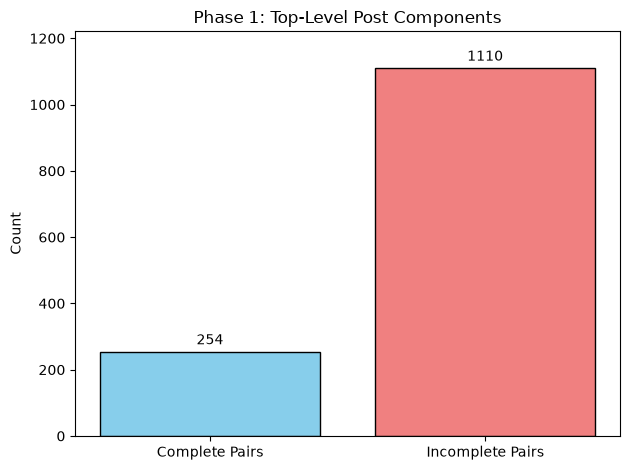

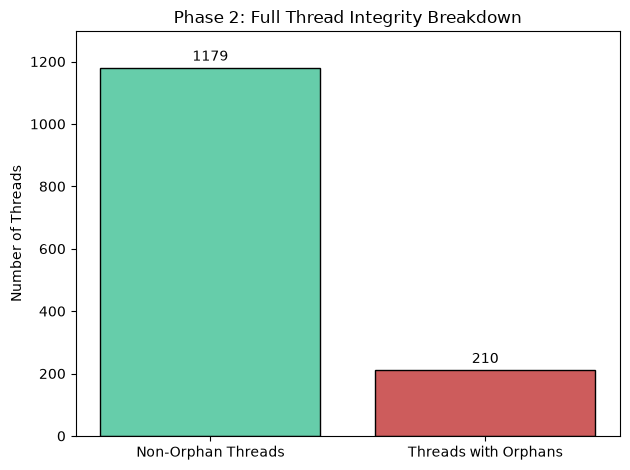

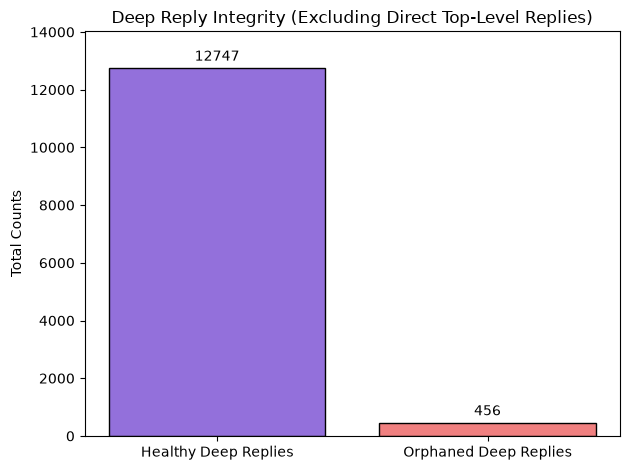

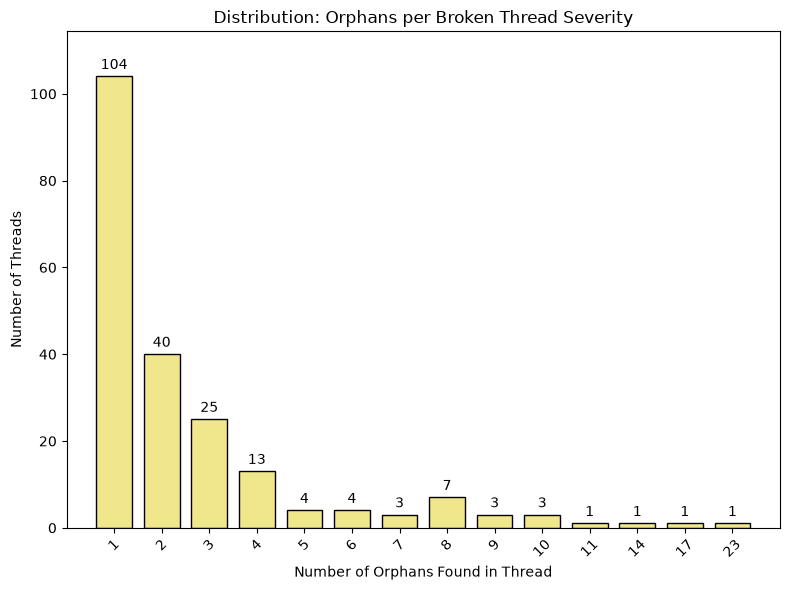

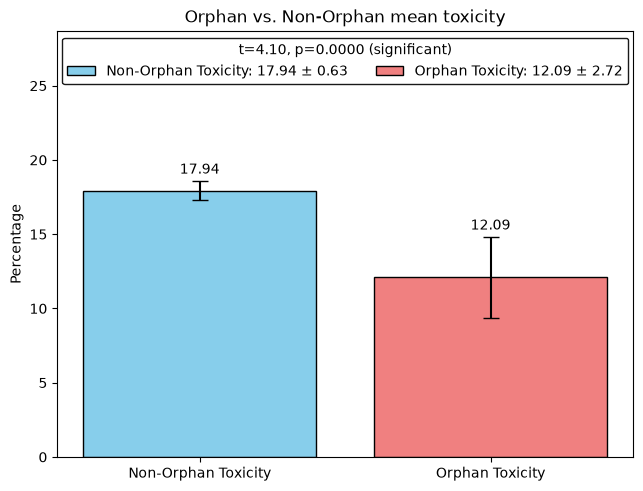

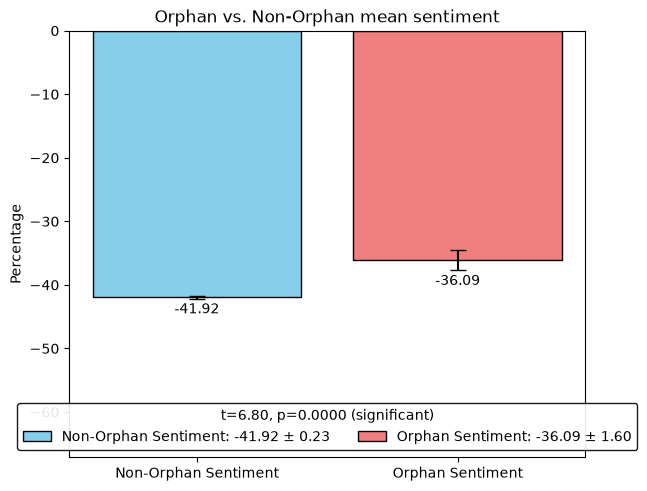

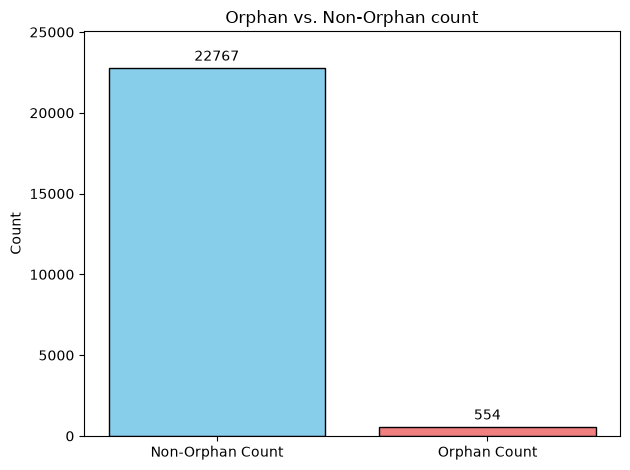

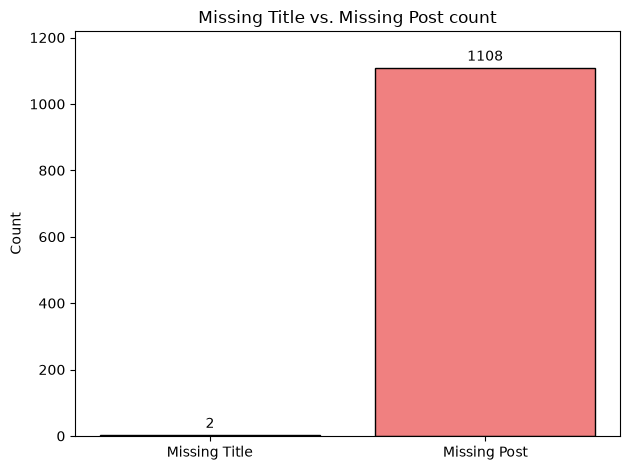

/tmp/ipykernel_2229600/2715717979.py:58: UserWarning: Mismatched number of handles and labels: len(handles) = 12 len(labels) = 2
  ax.legend(bars, legend_labels, title=legend_title, loc="upper right",


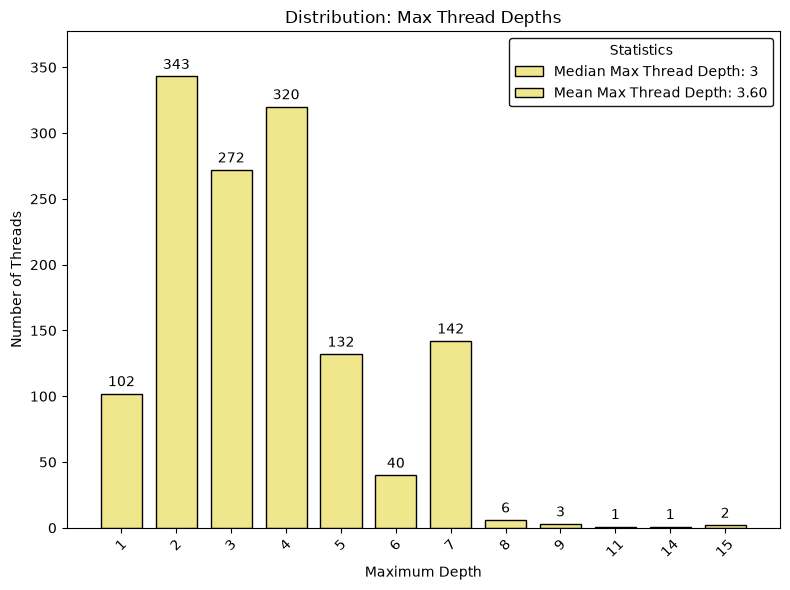

/tmp/ipykernel_2229600/2715717979.py:58: UserWarning: Mismatched number of handles and labels: len(handles) = 15 len(labels) = 2
  ax.legend(bars, legend_labels, title=legend_title, loc="upper right",


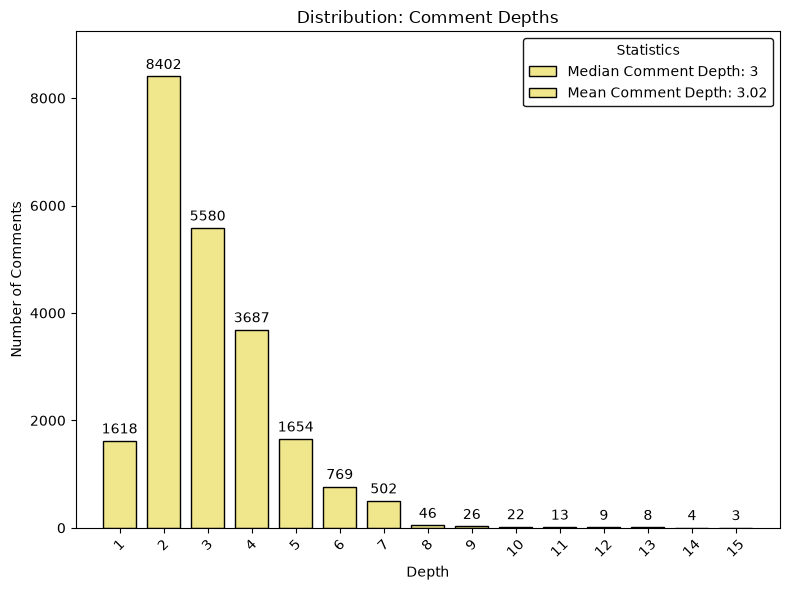

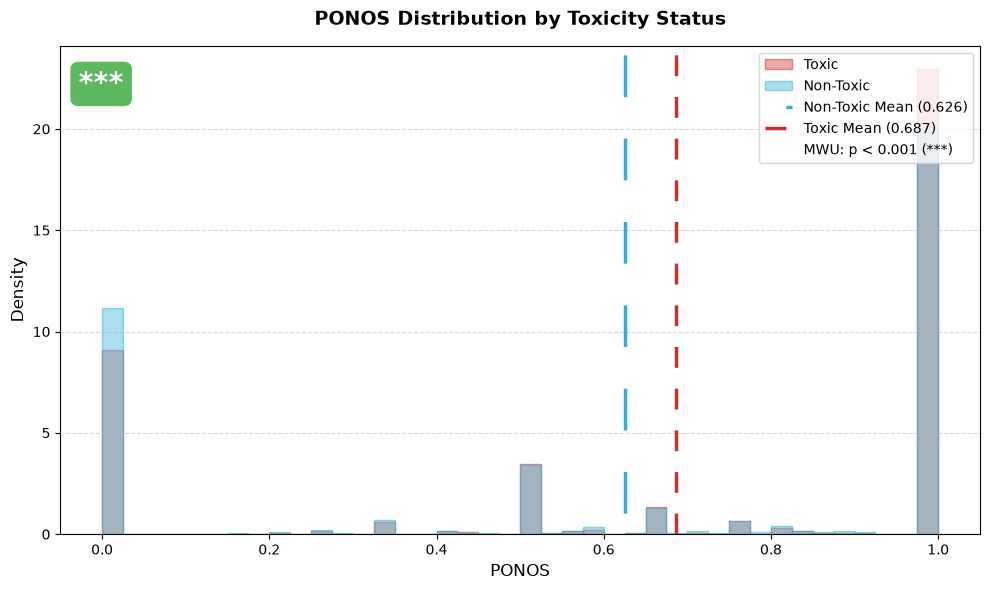

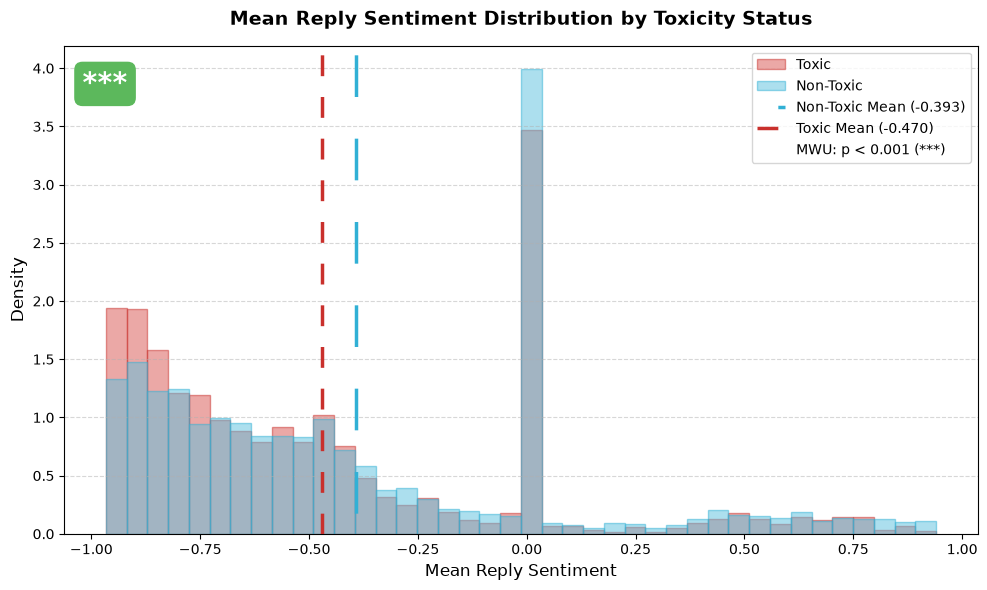

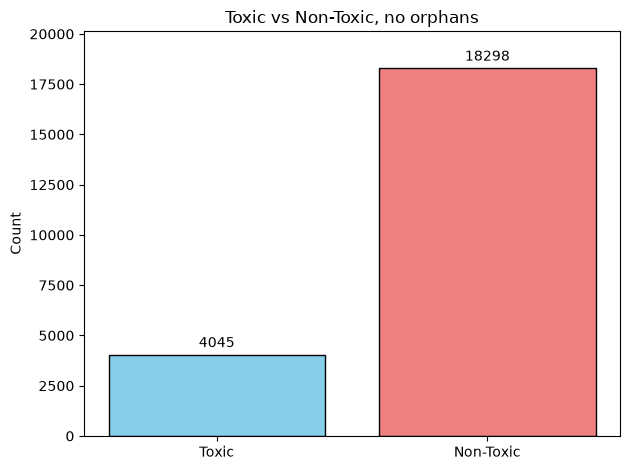

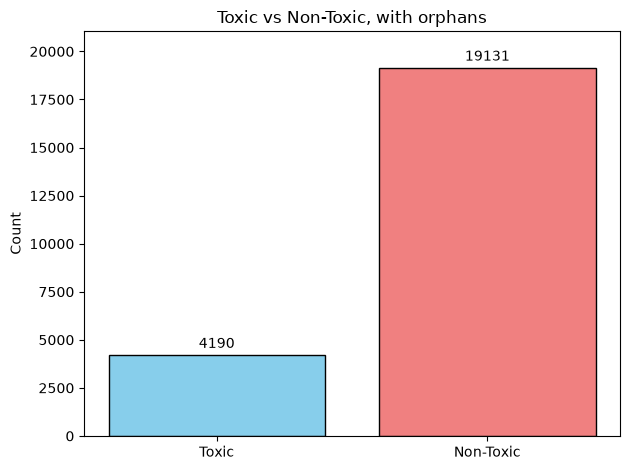

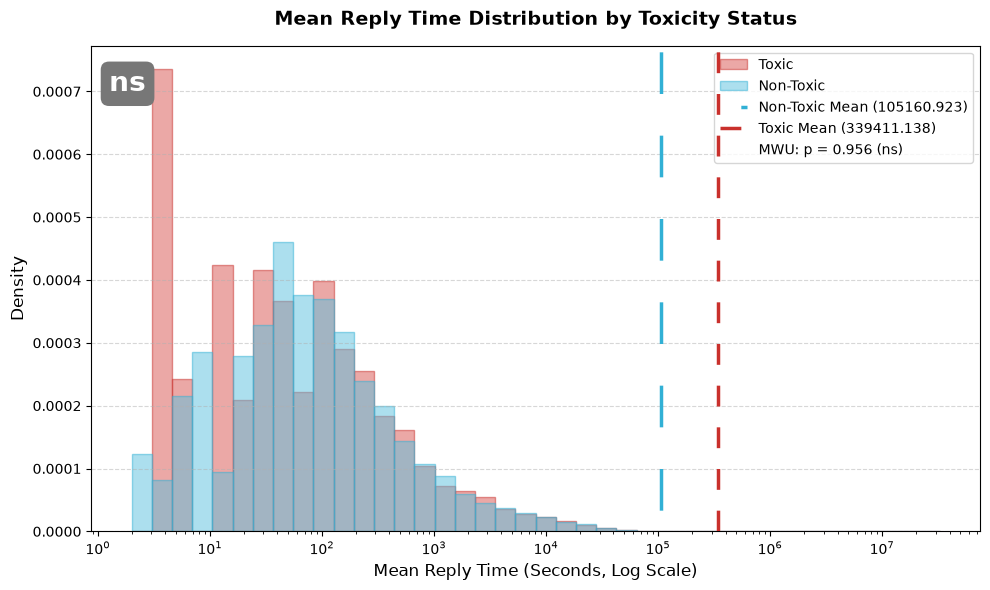

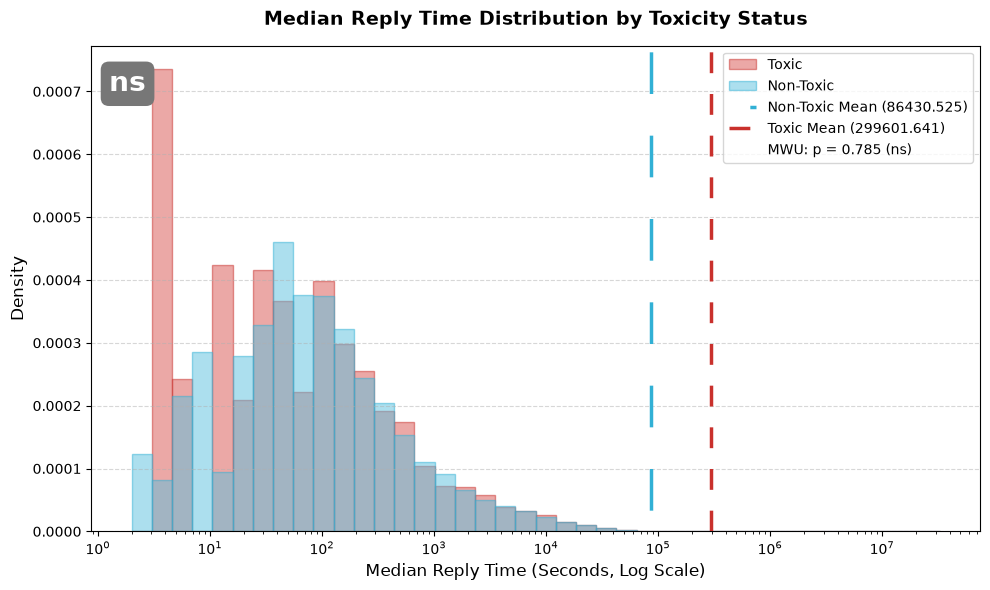

/tmp/ipykernel_2229600/2715717979.py:58: UserWarning: Mismatched number of handles and labels: len(handles) = 11 len(labels) = 2
  ax.legend(bars, legend_labels, title=legend_title, loc="upper right",


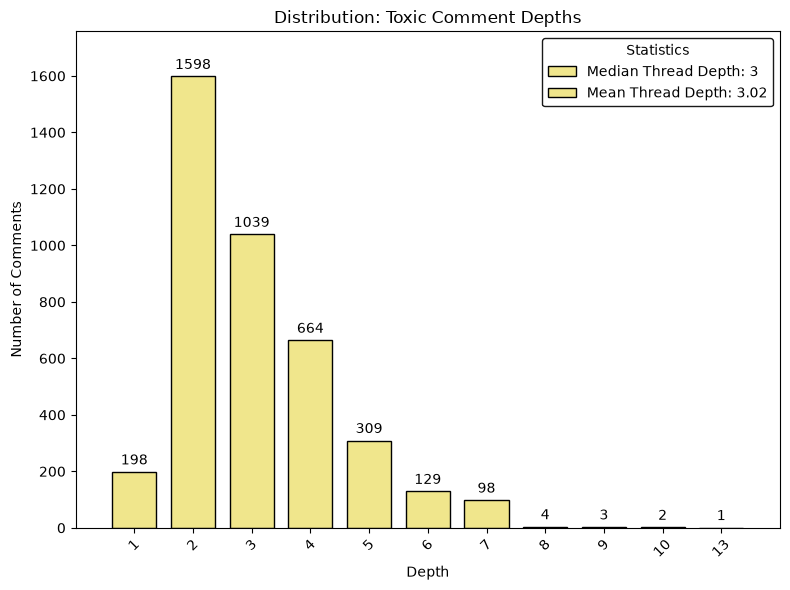

/tmp/ipykernel_2229600/2715717979.py:58: UserWarning: Mismatched number of handles and labels: len(handles) = 15 len(labels) = 2
  ax.legend(bars, legend_labels, title=legend_title, loc="upper right",


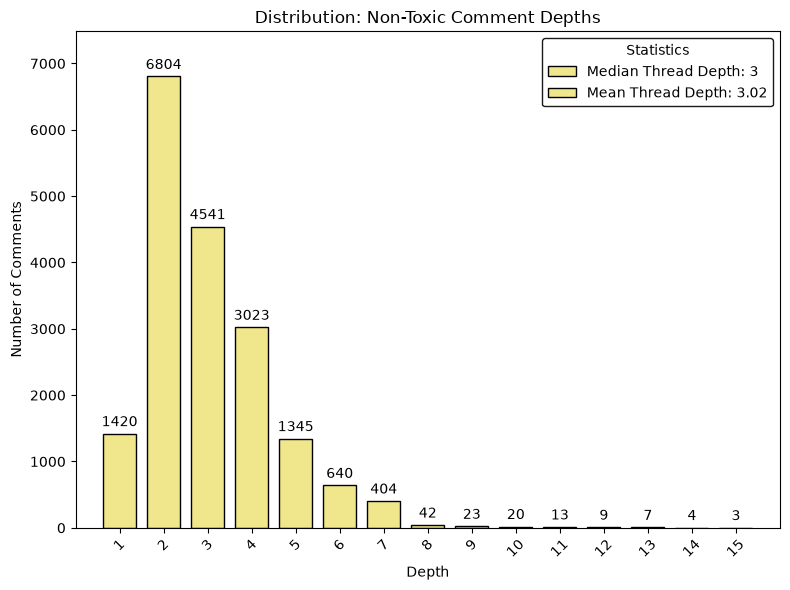

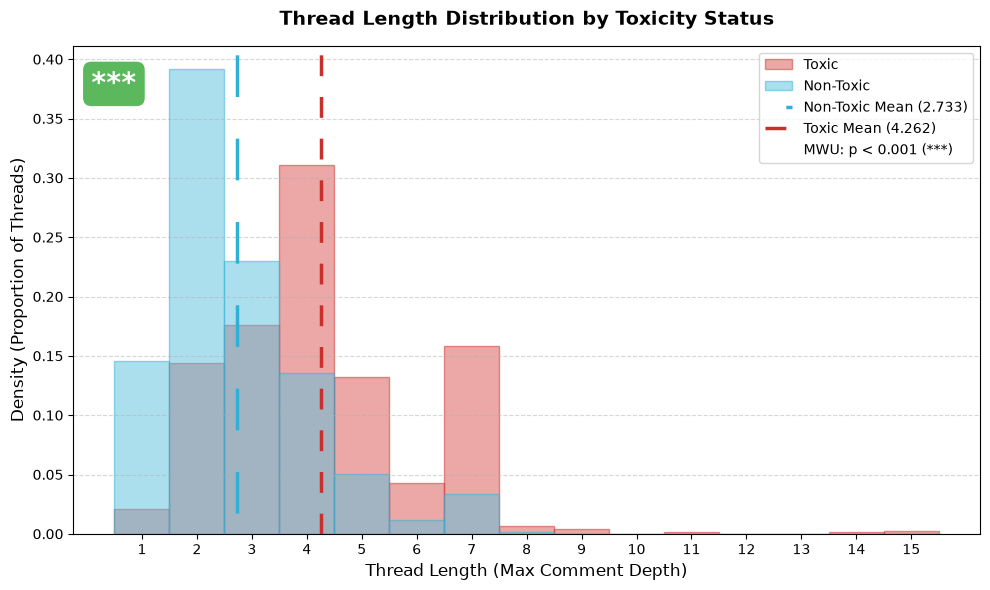

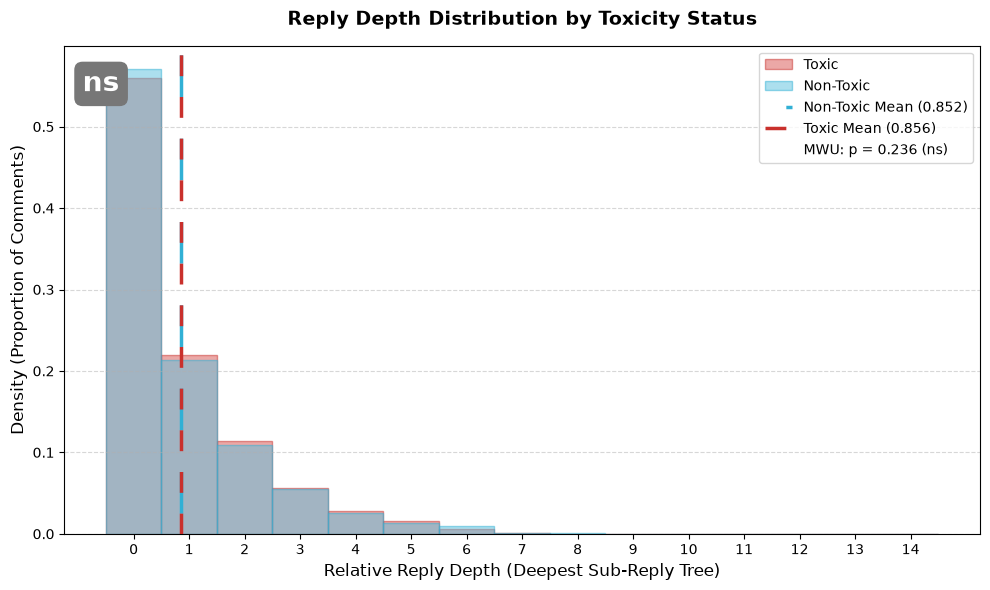

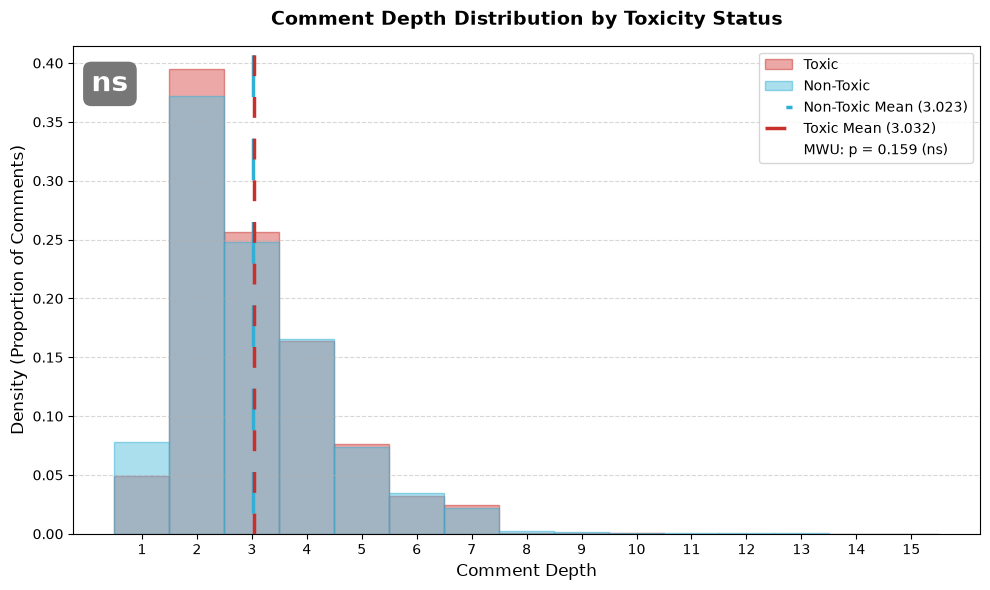

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Comment Depth Distribution by Toxicity Status'}, xlabel='Comment Depth', ylabel='Density (Proportion of Comments)'>)

In [ ]:
from scipy.stats import mannwhitneyu

# ============================================================
# Shared stats helpers
# ============================================================
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1 - 1) * a.std(ddof=1) ** 2 + (n2 - 1) * b.std(ddof=1) ** 2) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / pooled_std


def effect_size_label(d):
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    return "large"


# ============================================================
# Shared plotting helpers
# ============================================================
def simple_bar(categories, values, colors, title, ylabel, figsize=None):
    """Two/N-category count bar chart (Charts 1, 2, 3, 7, 8, 12, 13)."""
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(categories, values, color=colors, edgecolor="black")
    ax.bar_label(bars, padding=3)
    ax.set_ylim(0, max(values) * 1.1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    return fig, ax


def distribution_bar(distribution, title, xlabel, ylabel, legend_labels=None, legend_title="Statistics"):
    """
    Wide categorical distribution bar chart (Charts 4, 9, 10, 15).
    `distribution` must already be a value_counts()-style Series sorted by index.
    """
    x_categories = distribution.index.astype(str)
    fig, ax = plt.subplots(figsize=(max(8, len(x_categories) * 0.5), 6))

    step, bar_width = 2.0, 1.5
    x_positions = np.arange(len(x_categories)) * step

    bars = ax.bar(x_positions, distribution.values, width=bar_width, color="khaki", edgecolor="black")
    ax.bar_label(bars, padding=3)

    if legend_labels:
        ax.legend(bars, legend_labels, title=legend_title, loc="upper right",
                  frameon=True, framealpha=0.9, edgecolor="black")

    if not distribution.empty:
        ax.set_ylim(0, max(distribution.values) * 1.1)
        ax.set_xlim(x_positions[0] - step, x_positions[-1] + step)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_categories, rotation=45, ha="center")

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()
    return fig, ax


def stat_compare_bar(labels, group_values, means, title, ylabel, invert=False, loc="upper center"):
    """
    Two-group mean comparison with Welch's t-test + Cohen's d + 95% MOE error bars
    (Charts 5, 6).
    """
    a, b = group_values
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    # d = cohens_d(a, b)
    moe = [1.96 * g.std(ddof=1) / np.sqrt(len(g)) for g in group_values]

    fig, ax = plt.subplots(constrained_layout=True)
    bars = ax.bar(labels, means, yerr=moe, capsize=6, color=["skyblue", "lightcoral"], edgecolor="black")
    ax.bar_label(bars, padding=3, fmt="%.2f")

    sig_text = "significant" if p_val < 0.05 else "not significant"
    if invert:
        ax.set_ylim(min(means) * 1.6, 0)
    else:
        ax.set_ylim(0, max(means) * 1.6)

    ax.set_title(title)
    ax.set_ylabel(ylabel)

    legend_labels = [f"{l}: {m:.2f} \u00b1 {e:.2f}" for l, m, e in zip(labels, means, moe)]
    ax.legend(
        bars, legend_labels,
        title=f"t={t_stat:.2f}, p={p_val:.4f} ({sig_text})",
        # title=f"t={t_stat:.2f}, p={p_val:.4f} ({sig_text})\nCohen's d={d:.2f} ({effect_size_label(d)})",
        loc=loc, ncol=2, frameon=True, framealpha=0.9, edgecolor="black",
    )
    plt.show()
    return fig, ax


def significance_stars(p):
    """Standard stats-paper convention for annotating significance."""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def histogram_compare(toxic_vals, non_toxic_vals, title, xlabel, ylabel="Density",
                       bins=40, integer_bins=False, log_scale=False):
    """
    Overlaid density histograms comparing toxic vs. non-toxic groups.
    """
    toxic_vals = np.asarray(toxic_vals, dtype=float)
    non_toxic_vals = np.asarray(non_toxic_vals, dtype=float)
    toxic_vals = toxic_vals[np.isfinite(toxic_vals)]
    non_toxic_vals = non_toxic_vals[np.isfinite(non_toxic_vals)]

    stat, p_value = mannwhitneyu(toxic_vals, non_toxic_vals, alternative="two-sided")
    stars = significance_stars(p_value)
    p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

    # --- BIN EDGE SELECTION ---
    if isinstance(bins, (np.ndarray, list)):
        bin_edges = np.asarray(bins)
    elif integer_bins:
        min_val = int(min(toxic_vals.min(), non_toxic_vals.min())) if len(toxic_vals) and len(non_toxic_vals) else 0
        max_val = int(max(toxic_vals.max(), non_toxic_vals.max()))
        bin_edges = np.arange(min_val, max_val + 2) - 0.5
    elif log_scale:
        toxic_vals = toxic_vals[toxic_vals > 0]
        non_toxic_vals = non_toxic_vals[non_toxic_vals > 0]
        lo = min(toxic_vals.min(), non_toxic_vals.min())
        hi = max(toxic_vals.max(), non_toxic_vals.max())
        lo = max(lo, 1e-3)
        bin_edges = np.logspace(np.log10(lo), np.log10(hi), bins + 1)
    else:
        lo = min(toxic_vals.min(), non_toxic_vals.min())
        hi = max(toxic_vals.max(), non_toxic_vals.max())
        bin_edges = np.linspace(lo, hi, bins + 1)

    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    if log_scale:
        ax.set_xscale("log")

    ax.hist(toxic_vals, bins=bin_edges, density=True, alpha=0.5,
            color="#d9534f", edgecolor="#c9302c", label="Toxic")
    ax.hist(non_toxic_vals, bins=bin_edges, density=True, alpha=0.5,
            color="#5bc0de", edgecolor="#31b0d5", label="Non-Toxic")

    # Calculate means
    t_mean = toxic_vals.mean()
    nt_mean = non_toxic_vals.mean()

    # 1. Non-Toxic: Blue dashed line (starts at 0 offset: 6px line, 6px gap)
    ax.axvline(
        nt_mean, color="#31b0d5", linewidth=2.5, zorder=5,
        dashes=(0, 6, 6),
        label=f"Non-Toxic Mean ({nt_mean:.3f})"
    )

    # 2. Toxic: Red dashed line (starts at 6px offset: interlocks in blue gaps)
    ax.axvline(
        t_mean, color="#c9302c", linewidth=2.5, zorder=6,
        dashes=(6, 6, 6),
        label=f"Toxic Mean ({t_mean:.3f})"
    )

    handles, labels = ax.get_legend_handles_labels()
    handles.append(plt.Rectangle((0, 0), 0, 0, fill=False, edgecolor="none", visible=False))
    labels.append(f"MWU: {p_text} ({stars})")
    ax.legend(handles, labels, loc="upper right", frameon=True, fontsize=10)

    badge_color = "#5cb85c" if p_value < 0.05 else "#777777"
    ax.text(
        0.02, 0.95, stars, transform=ax.transAxes, fontsize=20, fontweight="bold",
        color="white", ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=badge_color, edgecolor="none"),
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    if integer_bins:
        ax.set_xticks(np.arange(bin_edges[0] + 0.5, bin_edges[-1]))
        
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    return fig, ax

def histogram_compare_zero_inclusive(toxic_vals, non_toxic_vals, title, xlabel, ylabel="Density"):
    toxic_vals = np.asarray(toxic_vals, dtype=float)
    non_toxic_vals = np.asarray(non_toxic_vals, dtype=float)
    
    min_val = int(min(toxic_vals.min(), non_toxic_vals.min()))
    max_val = int(max(toxic_vals.max(), non_toxic_vals.max()))
    
    # Bins centered on integers starting from 0 (e.g., -0.5 to 0.5 captures 0)
    bin_edges = np.arange(min_val, max_val + 2) - 0.5
    
    histogram_compare(
        toxic_vals, non_toxic_vals,
        title, xlabel, ylabel=ylabel,
        bins=bin_edges
    )


def toxic_counts(series):
    """Safe replacement for series.value_counts()[1] / [0] (won't KeyError if a class is absent)."""
    vc = series.value_counts().reindex([0, 1], fill_value=0)
    return vc[1], vc[0]  # toxic, non_toxic


# ============================================================
# CHART 1: Phase 1: Top-Level Post Components
# ============================================================
simple_bar(
    ["Complete Pairs", "Incomplete Pairs"],
    [complete_pairs, incomplete_pairs],
    ["skyblue", "lightcoral"],
    "Phase 1: Top-Level Post Components",
    "Count",
)

# ============================================================
# CHART 2: Phase 2: Full Thread Integrity Breakdown
# ============================================================
simple_bar(
    ["Non-Orphan Threads", "Threads with Orphans"],
    [complete_threads, orphan_threads],
    ["mediumaquamarine", "indianred"],
    "Phase 2: Full Thread Integrity Breakdown",
    "Number of Threads",
)

# ============================================================
# CHART 3: Deep Nested Reply Integrity (Excludes Direct Top-Level Replies)
# ============================================================
deep_reply_mask = df["info_order"].str.count(",") > 1
all_deep_reply_rows_count = deep_reply_mask.sum()
total_orphaned_deep_replies = (orphan_rows["info_order"].str.count(",") > 1).sum()
total_non_orphan_deep_replies = all_deep_reply_rows_count - total_orphaned_deep_replies

simple_bar(
    ["Healthy Deep Replies", "Orphaned Deep Replies"],
    [total_non_orphan_deep_replies, total_orphaned_deep_replies],
    ["mediumpurple", "lightcoral"],
    "Deep Reply Integrity (Excluding Direct Top-Level Replies)",
    "Total Counts",
)

# ============================================================
# CHART 4: Wide Distribution of Orphans per Thread
# ============================================================
distribution4 = pd.Series(sub_reply_orphan_counts).value_counts().sort_index()
distribution_bar(
    distribution4,
    "Distribution: Orphans per Broken Thread Severity",
    "Number of Orphans Found in Thread",
    "Number of Threads",
)

# ============================================================
# CHART 5: Orphan vs. Non-Orphan Toxicity
# ============================================================
orphan_toxicity_values = orphan_rows["toxic"] * 100
non_orphan_toxicity_values = non_orphan_rows["toxic"] * 100

stat_compare_bar(
    ["Non-Orphan Toxicity", "Orphan Toxicity"],
    [non_orphan_toxicity_values, orphan_toxicity_values],
    [mean_toxicity_non_orphan_percent, mean_toxicity_orphan_percent],
    "Orphan vs. Non-Orphan mean toxicity",
    "Percentage",
)

# ============================================================
# CHART 6: Orphan vs. Non-Orphan Sentiment
# ============================================================
orphan_sentiment_values = orphan_rows["top_sentiment_score"] * 100
non_orphan_sentiment_values = df.loc[~df.index.isin(orphan_rows.index), "top_sentiment_score"] * 100

stat_compare_bar(
    ["Non-Orphan Sentiment", "Orphan Sentiment"],
    [non_orphan_sentiment_values, orphan_sentiment_values],
    [non_orphan_mean_sentiment_percent, orphan_mean_sentiment_percent],
    "Orphan vs. Non-Orphan mean sentiment",
    "Percentage",
    invert=True,
    loc="lower center",
)

# ============================================================
# CHART 7: Orphan vs. Non-Orphan Counts
# ============================================================
n_orphan = len(orphan_rows)
n_non_orphan = len(df) - n_orphan
simple_bar(
    ["Non-Orphan Count", "Orphan Count"],
    [n_non_orphan, n_orphan],
    ["skyblue", "lightcoral"],
    "Orphan vs. Non-Orphan count",
    "Count",
)

# ============================================================
# CHART 8: Missing Title vs. Missing Post Counts
# ============================================================
simple_bar(
    ["Missing Title", "Missing Post"],
    [missing_title, missing_post],
    ["skyblue", "lightcoral"],
    "Missing Title vs. Missing Post count",
    "Count",
)

# ============================================================
# CHART 9: Max Thread Depth Distribution
# ============================================================
distribution9 = max_depths.value_counts().sort_index()
distribution_bar(
    distribution9,
    "Distribution: Max Thread Depths",
    "Maximum Depth",
    "Number of Threads",
    legend_labels=[
        f"Median Max Thread Depth: {np.median(max_depths):.0f}",
        f"Mean Max Thread Depth: {np.mean(max_depths):.2f}",
    ],
)

# ============================================================
# CHART 10: Comment Depth Distribution
# ============================================================
comment_depth = df_f["comment_depth"]  # cached: reused by charts 10, 15
distribution10 = comment_depth.value_counts().sort_index()
distribution_bar(
    distribution10,
    "Distribution: Comment Depths",
    "Depth",
    "Number of Comments",
    legend_labels=[
        f"Median Comment Depth: {np.median(comment_depth):.0f}",
        f"Mean Comment Depth: {np.mean(comment_depth):.2f}",
    ],
)

# ============================================================
# CHART 11: PONOS / sentiment distributions, toxic vs. non-toxic
# ============================================================
ponos = df_f["ponos"]
mean_children_sentiment = df_f["children_mean_sentiment"]
toxicity = df_f["toxic"]
toxic_mask = toxicity == 1  # cached: reused by charts 11, 14

histogram_compare(
    ponos[toxic_mask].to_numpy(), ponos[~toxic_mask].to_numpy(),
    "PONOS Distribution by Toxicity Status", "PONOS",
)
histogram_compare(
    mean_children_sentiment[toxic_mask].to_numpy(), mean_children_sentiment[~toxic_mask].to_numpy(),
    "Mean Reply Sentiment Distribution by Toxicity Status", "Mean Reply Sentiment",
)

# ============================================================
# CHART 12 / 13: Toxic vs Non-Toxic (with / without orphans)
# ============================================================
toxic_f, non_toxic_f = toxic_counts(df_f["toxic"])
simple_bar(
    ["Toxic", "Non-Toxic"], [toxic_f, non_toxic_f],
    ["skyblue", "lightcoral"], "Toxic vs Non-Toxic, no orphans", "Count",
)

toxic_all, non_toxic_all = toxic_counts(df["toxic"])
simple_bar(
    ["Toxic", "Non-Toxic"], [toxic_all, non_toxic_all],
    ["skyblue", "lightcoral"], "Toxic vs Non-Toxic, with orphans", "Count",
)

# ============================================================
# CHART 14: Reply time distributions, toxic vs. non-toxic (LOG SCALE)
# ============================================================
mean_reply_time = df_f["mean_delay_seconds"]
median_reply_time = df_f["median_delay_seconds"]

histogram_compare(
    mean_reply_time[toxic_mask].to_numpy(), mean_reply_time[~toxic_mask].to_numpy(),
    "Mean Reply Time Distribution by Toxicity Status", "Mean Reply Time (Seconds, Log Scale)",
    log_scale=True,
)
histogram_compare(
    median_reply_time[toxic_mask].to_numpy(), median_reply_time[~toxic_mask].to_numpy(),
    "Median Reply Time Distribution by Toxicity Status", "Median Reply Time (Seconds, Log Scale)",
    log_scale=True,
)

# ============================================================
# CHART 15: Toxicity / Comment Depth Distribution
# ============================================================
depth_by_toxicity = df_f.groupby("toxic")["comment_depth"].value_counts().sort_index()
depth_stats_legend = [
    f"Median Thread Depth: {np.median(comment_depth):.0f}",
    f"Mean Thread Depth: {np.mean(comment_depth):.2f}",
]

distribution_bar(
    depth_by_toxicity.loc[1].sort_index(),
    "Distribution: Toxic Comment Depths", "Depth", "Number of Comments",
    legend_labels=depth_stats_legend,
)
distribution_bar(
    depth_by_toxicity.loc[0].sort_index(),
    "Distribution: Non-Toxic Comment Depths", "Depth", "Number of Comments",
    legend_labels=depth_stats_legend,
)

# ============================================================
# CHART 16: Thread Length Distribution by Toxicity Status
# ============================================================
histogram_compare(
    toxic_thread_lengths, non_toxic_thread_lengths,
    "Thread Length Distribution by Toxicity Status", "Thread Length (Max Comment Depth)",
    ylabel="Density (Proportion of Threads)", integer_bins=True,
)

# ============================================================
# CHART 17: Reply Depth Distribution by Toxicity Status
# ============================================================
histogram_compare(
    df_f[df_f["toxic"] == 1]["max_reply_depth"],
    df_f[df_f["toxic"] == 0]["max_reply_depth"],
    "Reply Depth Distribution by Toxicity Status",
    "Relative Reply Depth (Deepest Sub-Reply Tree)",
    ylabel="Density (Proportion of Comments)",
    integer_bins=True,
)

# ============================================================
# CHART 18: Comment Depth Distribution by Toxicity Status
# ============================================================
histogram_compare(
    df_f[df_f["toxic"] == 1]["comment_depth"],
    df_f[df_f["toxic"] == 0]["comment_depth"],
    "Comment Depth Distribution by Toxicity Status",
    "Comment Depth",
    ylabel="Density (Proportion of Comments)",
    integer_bins=True,
)